# 타이타닉 생존자 분석 — 룰베이스 분류 도출 (실습)

## 분석 시나리오
1912년 4월, 타이타닉호가 빙산과 충돌해 침몰했다. 891명 승객의 인적사항(나이, 성별, 객실등급, 요금, 호칭 등)과 생존 여부 데이터가 있다.
어떤 사람들이 생존했는지 패턴을 찾고, 단순한 룰만으로 생존 여부를 예측할 수 있는지 확인해본다.

## 분석 흐름
1. **데이터 파악** — 컬럼, 결측치, 분포 
2. **시각화 탐색** — 변수별 생존율 비교 
3. **호칭 파생** — 이름에서 호칭 추출, 호칭별 생존율 
4. **인사이트 정리** — 어떤 변수가 생존을 좌우하는가
5. **룰 도출 및 검증** — 룰 정의 후 정확도/recall 평가 

## 데이터
- 파일: `타이타닉_데이터.csv` (891행, 11컬럼)
- 타겟: `생존여부` (`생존` / `사망`)

> **참고:** 본 데이터는 캐글 Titanic Competition의 `train.csv`를 한국어로 가공한 것이다.

---

## 0. 환경 준비

- 다음을 실행하여 환경을 준비하시오.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 자동 감지
candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
              'Noto Sans CJK KR', 'Noto Sans KR', 'DejaVu Sans']
available = {f.name for f in fm.fontManager.ttflist}
for font in candidates:
    if font in available:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
pd.set_option('display.max_columns', None)

- 다음 프롬프트로 AI를 단계별 데이터 분석 도우미로 세팅하시오.

```
# 역할
당신은 유능한 15년차 데이터 분석가입니다.
주어진 데이터에 대해서 공학 박사급 통찰력을 발휘하여 데이터 분석 코드를 작성하세요.

# 환경
데이터를 당신에게 모두 업로드 할 수 없는 환경입니다. 
데이터 샘플 100행 정도를 첨부하면 전체 데이터의 스키마를 파악하고 사용자 질문에 대응하세요.
한글 출력 환경이 세팅되어 있기 때문에 sns.set_style("whitegrid") 같이 따로 스타일을 초기화 하지 마세요.

# 응답
친절하고 상대방을 존중하는 톤으로 이야기합니다. 늘 충실한 데이터 분석가 동료입장을 유지하세요.
너무 많은 정보를 한꺼번에 주지 말고 단계적으로 사용자의 요구에 응답하세요.

# 분석의 범위
EDA를 수행하고 의미있는 변수를 추출합니다.
이 결과로 부터 데이터의 인사이트를 넣고 의사결정에 도움이 될만한 룰을 발굴합니다.
ML 모델링은 범위에 포함되지 않습니다.
```

---
## 1. 데이터 파악

### 과제 1-1. 데이터를 불러오고 모양과 처음 5행을 확인하시오.

In [2]:
df = pd.read_csv('타이타닉_데이터.csv')
print('데이터 모양:', df.shape)
df.head()

데이터 모양: (891, 11)


,생존여부,객실등급,이름,성별,나이,동승형제배우자수,동승부모자녀수,티켓번호,요금,객실번호,승선항
0,사망,3,"Braund, Mr. Owen Harris",남,22.0,1,0,A/5 21171,7.2500,NaN,사우샘프턴
1,생존,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",여,38.0,1,0,PC 17599,71.2833,C85,셰르부르
2,생존,3,"Heikkinen, Miss. Laina",여,26.0,0,0,STON/O2. 3101282,7.9250,NaN,사우샘프턴
3,생존,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",여,35.0,1,0,113803,53.1000,C123,사우샘프턴
4,사망,3,"Allen, Mr. William Henry",남,35.0,0,0,373450,8.0500,NaN,사우샘프턴


**해석:** 891행, 11개 컬럼. 각 행은 한 명의 승객 정보다. `이름`, `티켓번호`, `객실번호` 같은 식별성 컬럼과 `생존여부`, `객실등급`, `성별`, `나이`, `요금`, `승선항` 등 분석 가능한 컬럼이 있다.

### 과제 1-2. 각 컬럼의 데이터 타입과 결측치를 확인하시오.

In [3]:
print(df.info())
print('\n결측치 개수:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   생존여부      891 non-null    object 
 1   객실등급      891 non-null    int64  
 2   이름        891 non-null    object 
 3   성별        891 non-null    object 
 4   나이        714 non-null    float64
 5   동승형제배우자수  891 non-null    int64  
 6   동승부모자녀수   891 non-null    int64  
 7   티켓번호      891 non-null    object 
 8   요금        891 non-null    float64
 9   객실번호      204 non-null    object 
 10  승선항       889 non-null    object 
dtypes: float64(2), int64(3), object(6)
memory usage: 76.7+ KB
None

결측치 개수:
생존여부          0
객실등급          0
이름            0
성별            0
나이          177
동승형제배우자수      0
동승부모자녀수       0
티켓번호          0
요금            0
객실번호        687
승선항           2
dtype: int64


**해석:** 세 컬럼에 결측치가 있다.
- `나이`: 177건 결측 (전체의 약 20%)
- `객실번호`: 687건 결측 (약 77%) — 너무 많아서 직접 사용은 어려움
- `승선항`: 2건 결측 (무시 가능)

`객실번호`는 결측이 많아 우리 분석에서는 제외할 가능성이 높다.

### 과제 1-3. 수치형 변수의 기초 통계량을 확인하시오.

In [4]:
df.describe()

,객실등급,나이,동승형제배우자수,동승부모자녀수,요금
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,2.000000,20.125000,0.000000,0.000000,7.910400
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,38.000000,1.000000,0.000000,31.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200


**해석:** 나이는 0.42세 ~ 80세 범위(아기 포함). 요금은 0 ~ 512달러로 편차가 매우 큼 — 이상치 또는 1등석 고가 티켓이 있을 가능성. 객실등급은 1/2/3 (1이 최고급).

### 과제 1-4. 타겟 변수 `생존여부`의 분포를 확인하시오.

생존여부
사망    549
생존    342
Name: count, dtype: int64

생존률: 0.384


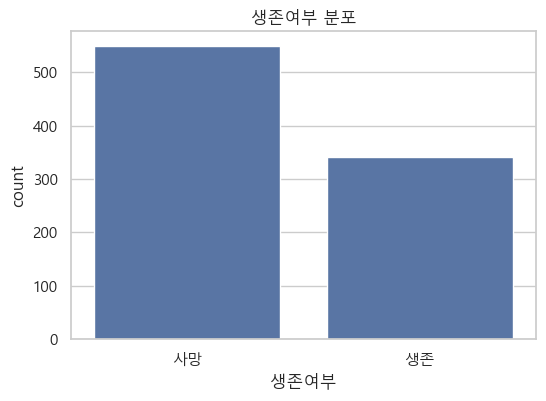

In [5]:
print(df['생존여부'].value_counts())
print(f"\n생존률: {(df['생존여부']=='생존').mean():.3f}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='생존여부', order=['사망', '생존'])
plt.title('생존여부 분포')
plt.show()

**해석:** 사망 549명, 생존 342명. 생존률 38.4%. **베이스라인(모두 사망 예측)의 정확도가 61.6%** 라는 의미 — 우리가 만들 룰은 이보다 명확하게 높아야 의미가 있다.

### 과제 1-5. 범주형 변수의 카테고리별 빈도를 확인하시오.

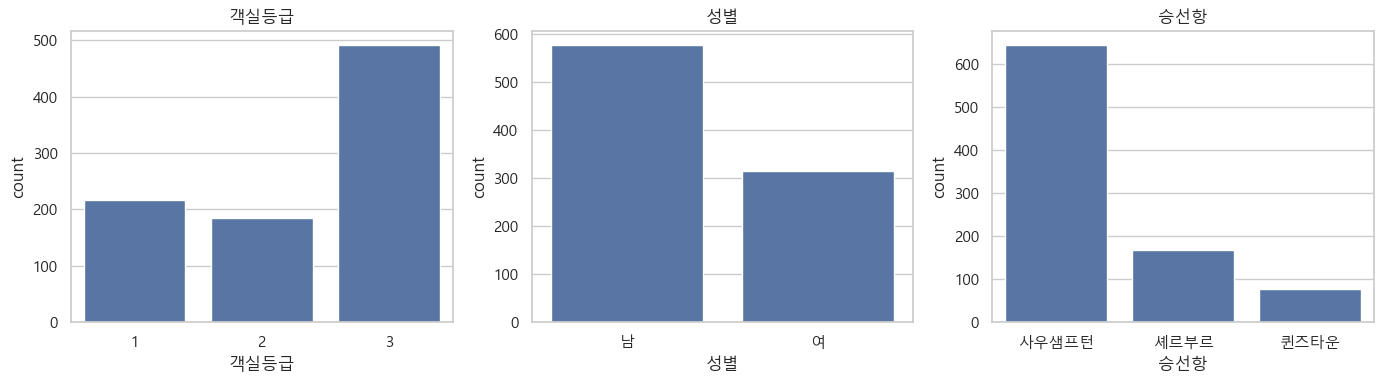

In [6]:
cat_cols = ['객실등급', '성별', '승선항']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**해석:** 3등석이 491명으로 압도적으로 많고, 1등석 216명, 2등석 184명. 남성이 577명으로 여성 314명보다 많다. 사우샘프턴 출발이 644명으로 대부분.

---
## 2. 시각화 탐색

이제 각 변수가 생존여부와 어떤 관계가 있는지 살펴본다.

### 과제 2-1. 수치형 변수들의 분포를 확인하시오.

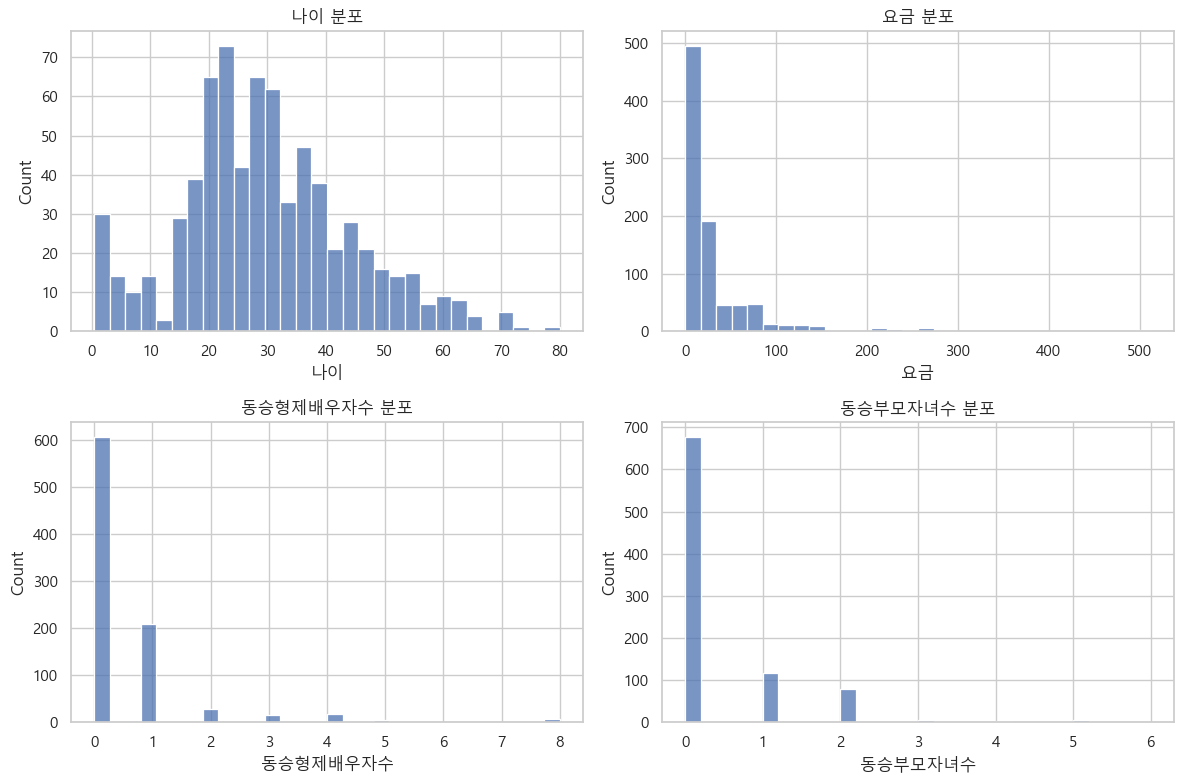

In [7]:
num_cols = ['나이', '요금', '동승형제배우자수', '동승부모자녀수']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(data=df, x=col, bins=30, ax=ax)
    ax.set_title(f'{col} 분포')
plt.tight_layout()
plt.show()

**해석:**
- **나이:** 20~30대가 가장 많고, 어린이도 일정 비율 있음 (어린이는 생존에 영향이 있을 수 있음)
- **요금:** 대부분 50달러 이하지만 200달러 넘는 고액 티켓도 일부 있음 — 오른쪽으로 치우친 분포
- **동승가족수:** 대부분 0~1명, 즉 혼자 또는 부부/형제 정도가 다수

### 과제 2-2. 수치형 변수 각각에 대해 `생존여부`별 박스플롯을 그려 비교하시오.

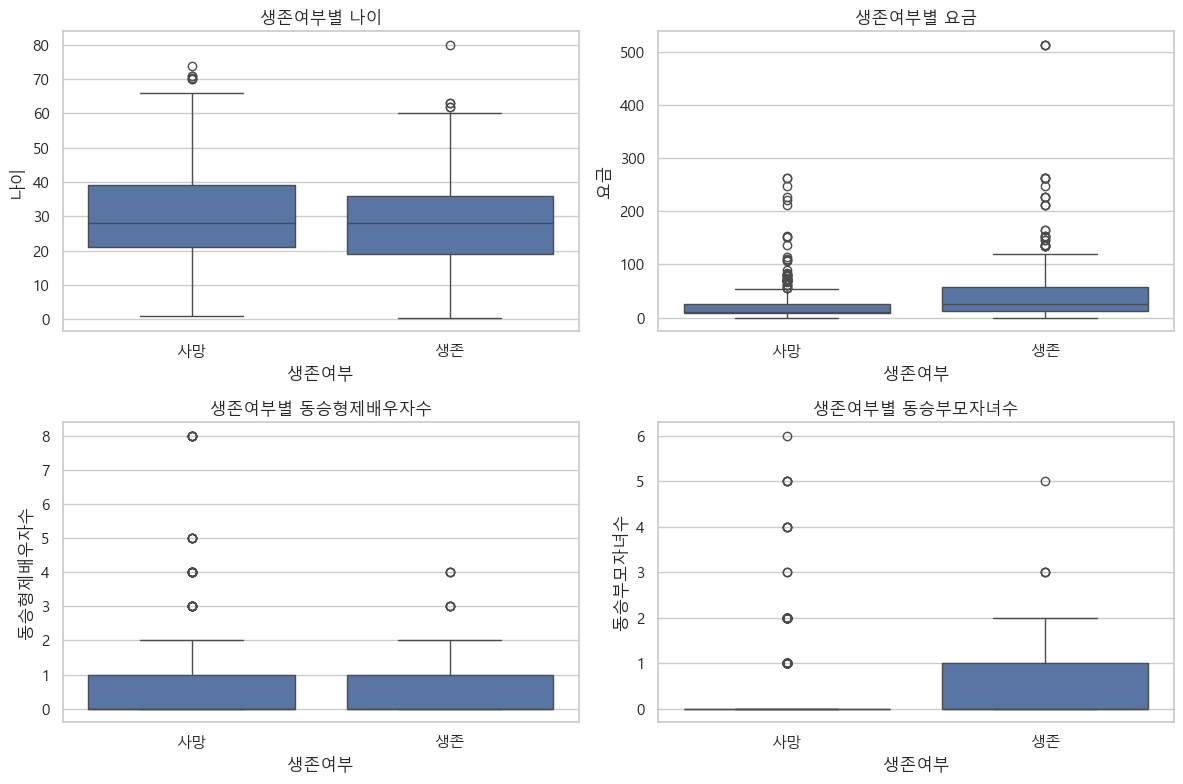

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x='생존여부', y=col, order=['사망', '생존'], ax=ax)
    ax.set_title(f'생존여부별 {col}')
plt.tight_layout()
plt.show()

**해석:**
- **나이:** 두 그룹 분포가 비슷해 보이지만, 생존 그룹의 하위 25%(아래쪽 박스)가 사망 그룹보다 살짝 더 어림 — 어린이 효과가 있을 가능성
- **요금:** 생존 그룹의 요금이 명확히 더 높다. **요금이 비싼 사람이 더 많이 생존했다** — 1등석 효과 추정
- **동승가족수:** 큰 차이 없음

요금이 가장 강한 시그널로 보인다.

### 과제 2-3. 객실등급별 생존율을 확인하시오.

   객실등급       생존율   건수
0     1  0.629630  216
1     2  0.472826  184
2     3  0.242363  491


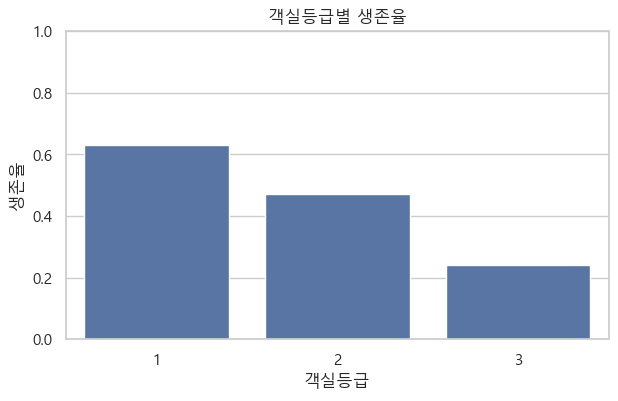

In [9]:
class_table = df.groupby('객실등급')['생존여부'].apply(
    lambda s: (s == '생존').mean()
).reset_index(name='생존율')
class_table['건수'] = df['객실등급'].value_counts().sort_index().values
print(class_table)

plt.figure(figsize=(7, 4))
sns.barplot(data=class_table, x='객실등급', y='생존율')
plt.title('객실등급별 생존율')
plt.ylim(0, 1.0)
plt.show()

**해석 — 강한 시그널 발견.**
- 1등석: 63.0% 생존
- 2등석: 47.3% 생존
- 3등석: 24.2% 생존

객실등급이 높을수록 생존율이 명확히 높다. 1등석은 전체 평균(38.4%)보다 훨씬 높고, 3등석은 훨씬 낮다. **룰 후보: 1등석 → 생존**

### 과제 2-4. 성별 생존율을 확인하시오.

  성별       생존율   건수
0  남  0.188908  577
1  여  0.742038  314


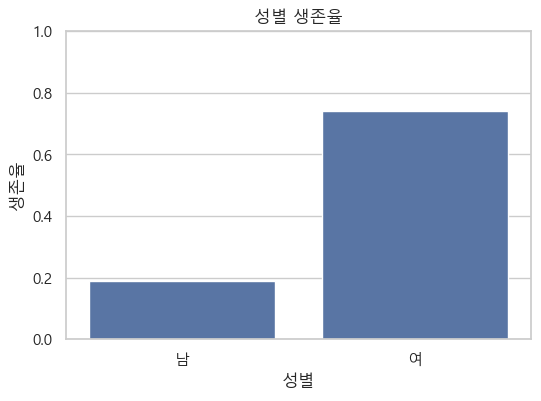

In [10]:
gender_table = df.groupby('성별')['생존여부'].apply(
    lambda s: (s == '생존').mean()
).reset_index(name='생존율')
gender_table['건수'] = df['성별'].value_counts().values
print(gender_table)

plt.figure(figsize=(6, 4))
sns.barplot(data=gender_table, x='성별', y='생존율')
plt.title('성별 생존율')
plt.ylim(0, 1.0)
plt.show()

**해석 — 가장 강한 시그널.**
- 여성: **74.2% 생존**
- 남성: 18.9% 생존

성별 차이가 너무나 명확하다. "Women and children first(여성과 어린이 먼저)" 원칙이 실제 데이터에서 그대로 보인다. **룰 후보: 여성 → 생존**

### 과제 2-5. 나이 구간별 생존율을 확인하시오.

        나이_구간       생존율   건수
0   0~12(어린이)  0.579710   69
1  13~18(청소년)  0.428571   70
2   19~30(청년)  0.355556  270
3   31~50(중년)  0.423237  241
4     51+(노년)  0.343750   64


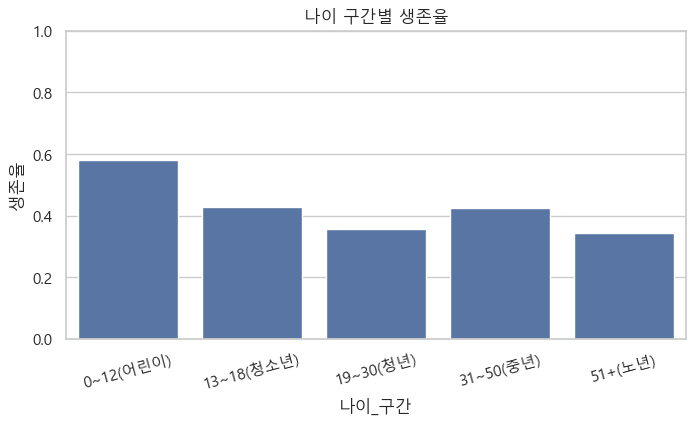

In [11]:
df['나이_구간'] = pd.cut(df['나이'],
                       bins=[0, 12, 18, 30, 50, 100],
                       labels=['0~12(어린이)', '13~18(청소년)', '19~30(청년)', '31~50(중년)', '51+(노년)'])
age_table = df.groupby('나이_구간', observed=True)['생존여부'].apply(
    lambda s: (s == '생존').mean()
).reset_index(name='생존율')
age_count = df['나이_구간'].value_counts().sort_index()
age_table['건수'] = age_count.values
print(age_table)

plt.figure(figsize=(8, 4))
sns.barplot(data=age_table, x='나이_구간', y='생존율')
plt.title('나이 구간별 생존율')
plt.ylim(0, 1.0)
plt.xticks(rotation=15)
plt.show()

**해석 — "어린이 먼저" 효과 확인.**
- **0 ~ 12세 어린이: 약 58% 생존** — 다른 연령대보다 명확히 높음
- 청소년~노년: 35 ~ 40% 수준으로 비슷

어린이는 생존에 유리하다. 다만 어린이는 전체에서 69명으로 비중이 작아 단독 룰의 적용 범위는 한정적. **룰 후보: 12세 이하 → 생존**

### 과제 2-6. 승선항별 생존율을 확인하시오.

     승선항       생존율   건수
0  사우샘프턴  0.336957  644
1   셰르부르  0.553571  168
2   퀸즈타운  0.389610   77


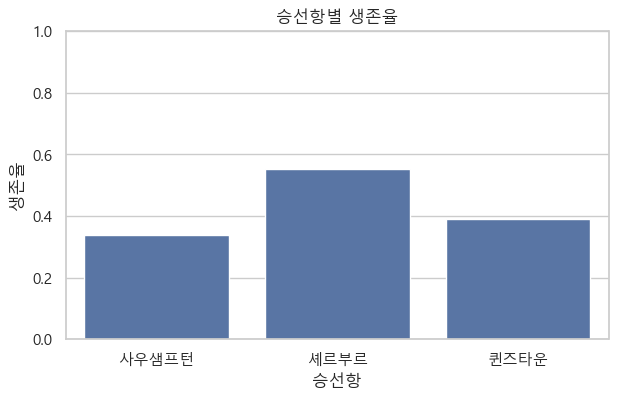

In [12]:
embark_table = df.dropna(subset=['승선항']).groupby('승선항')['생존여부'].apply(
    lambda s: (s == '생존').mean()
).reset_index(name='생존율')
embark_table['건수'] = df['승선항'].value_counts().values[:len(embark_table)]
print(embark_table)

plt.figure(figsize=(7, 4))
sns.barplot(data=embark_table, x='승선항', y='생존율')
plt.title('승선항별 생존율')
plt.ylim(0, 1.0)
plt.show()

**해석:** 셰르부르가 55%로 다른 항구(약 34~39%)보다 높지만, 이는 **셰르부르 출발 승객 중 1등석 비율이 높기 때문일 가능성**이 크다(교란변수). 승선항 자체가 생존을 결정한다고 보기는 어려움 — 룰 후보로는 약함.

### 과제 2-7. 동승가족수와 생존율의 관계를 확인하시오.

   총동승가족수       생존율   건수
0       0  0.303538  537
1       1  0.552795  161
2       2  0.578431  102
3       3  0.724138   29
4       4  0.200000   15
5       5  0.136364   22
6       6  0.333333   12
7       7  0.000000    6
8      10  0.000000    7


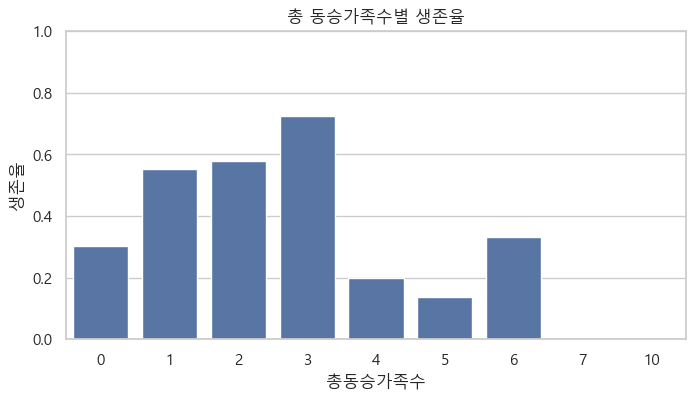

In [13]:
df['총동승가족수'] = df['동승형제배우자수'] + df['동승부모자녀수']

family_table = df.groupby('총동승가족수')['생존여부'].apply(
    lambda s: (s == '생존').mean()
).reset_index(name='생존율')
family_count = df['총동승가족수'].value_counts().sort_index()
family_table['건수'] = family_count.values
print(family_table)

plt.figure(figsize=(8, 4))
sns.barplot(data=family_table, x='총동승가족수', y='생존율')
plt.title('총 동승가족수별 생존율')
plt.ylim(0, 1.0)
plt.show()

**해석:** U자 형태가 살짝 보인다.
- 혼자(0명) 또는 대가족(4명+)은 생존율이 낮음
- 가족 1~3명과 함께면 생존율이 50% 이상으로 높음

다만 표본 수가 적은 구간이 있어 안정적인 룰로 만들기엔 부족. 참고용으로 기억해둘 패턴이다.

---
## 3. 호칭 파생

`이름` 컬럼을 자세히 보면 흥미로운 정보가 들어있다. 예를 들어:
- `Braund, Mr. Owen Harris`
- `Heikkinen, Miss. Laina`
- `Allen, Mrs. William Henry`

쉼표 다음, 마침표 앞에 **호칭(Title)** 이 있다 — Mr, Mrs, Miss, Master 등. 호칭은 그 사람의 성별, 결혼상태, 사회적 지위를 한 글자로 압축해 보여주는 정보다.

**왜 호칭이 중요한가?**
- 단순히 성별만 보면 남성은 거의 다 사망한 것처럼 보이지만, **남자아이(Master)는 생존율이 다르다**
- Mrs(기혼 여성)와 Miss(미혼 여성)도 다를 수 있다
- Dr, Rev 등 직함 정보도 들어있다

**핵심 스킬:** 정규표현식(regex)으로 텍스트에서 패턴을 추출하는 작업이다. 빈칸 채우기 식 작업으로는 LLM 도움이 가장 빛을 발하는 영역이다.

### 과제 3-1. `이름` 컬럼에서 호칭을 추출해 새 컬럼 `호칭`에 저장하시오.



In [14]:
df['호칭'] = df['이름'].str.extract(r',\s*([^.]+)\.')

print('이름 → 호칭 추출 예시:')
print(df[['이름', '호칭']].head(10))

이름 → 호칭 추출 예시:
                                                  이름      호칭
0                            Braund, Mr. Owen Harris      Mr
1  Cumings, Mrs. John Bradley (Florence Briggs Th...     Mrs
2                             Heikkinen, Miss. Laina    Miss
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)     Mrs
4                           Allen, Mr. William Henry      Mr
5                                   Moran, Mr. James      Mr
6                            McCarthy, Mr. Timothy J      Mr
7                     Palsson, Master. Gosta Leonard  Master
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)     Mrs
9                Nasser, Mrs. Nicholas (Adele Achem)     Mrs


**해석:** 이름에서 호칭이 깔끔하게 추출됐다. 정규표현식 한 줄로 891명 모두에게서 호칭을 뽑아냈다.

### 과제 3-2. 호칭별 빈도를 확인하시오.

In [15]:
title_counts = df['호칭'].value_counts()
print(title_counts)
print(f"\n총 호칭 종류: {df['호칭'].nunique()}개")

호칭
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

총 호칭 종류: 17개


**해석:** Mr/Miss/Mrs/Master 4개가 압도적으로 많고(전체의 약 97%), 나머지는 빈도가 매우 작다(Dr 7명, Rev 6명, Major/Col/Mlle 각 2명, 기타 1명씩). 빈도가 적은 호칭들은 별도 분석이 어려우니 **"Other"로 묶어 처리**한다.

### 과제 3-3. 빈도가 적은 호칭들을 `Other`로 묶어 `호칭_그룹` 컬럼을 만드시오.

In [16]:
common_titles = ['Mr', 'Mrs', 'Miss', 'Master']
df['호칭_그룹'] = df['호칭'].apply(lambda x: x if x in common_titles else 'Other')

print(df['호칭_그룹'].value_counts())

호칭_그룹
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64


**해석:** 5개 그룹으로 정리됐다 — Mr(517), Miss(182), Mrs(125), Master(40), Other(27).

### 과제 3-4. 호칭_그룹별 생존율을 확인하시오.

    호칭_그룹       생존율   건수
3     Mrs  0.792000   40
1    Miss  0.697802  182
0  Master  0.575000  517
4   Other  0.444444   27
2      Mr  0.156673  125


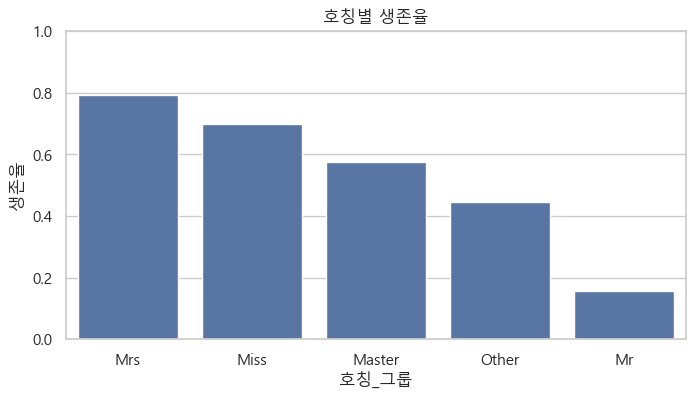

In [17]:
title_table = df.groupby('호칭_그룹')['생존여부'].apply(
    lambda s: (s == '생존').mean()
).reset_index(name='생존율')
title_table['건수'] = df['호칭_그룹'].value_counts().values
title_table = title_table.sort_values('생존율', ascending=False)
print(title_table)

plt.figure(figsize=(8, 4))
order = title_table.sort_values('생존율', ascending=False)['호칭_그룹'].tolist()
sns.barplot(data=title_table, x='호칭_그룹', y='생존율', order=order)
plt.title('호칭별 생존율')
plt.ylim(0, 1.0)
plt.show()

**해석 — 호칭으로 새로운 발견.**
- **Mrs (기혼 여성): 79.2% 생존** — 가장 높음
- **Miss (미혼 여성): 69.8% 생존**
- **Master (미혼 남성, 보통 어린 남자아이): 57.5% 생존** — 남성이지만 생존율 높음!
- Other (Dr, Rev 등): 44.4%
- **Mr (성인 남성): 15.7% 생존** — 가장 낮음

여기서 중요한 통찰이 있다.

1. **"여성 → 생존"이라는 룰을 더 세분화할 수 있음**: Mrs와 Miss로 나뉘는데, 둘 다 높지만 Mrs가 더 높다. 이는 결혼한 여성이 가족 단위로 우선 구조됐음을 시사할 수 있다.

2. **"남성 = 사망"이라는 단순한 룰의 예외**: Master는 남성이지만 생존율이 57.5%. 이는 실제로 **어린 남자아이**를 의미하는 호칭이다. 즉 단순히 "성별"만 봤다면 놓쳤을 패턴을 호칭이 잡아낸다.

3. **나이 결측치 보완 효과**: `나이` 컬럼은 177건이 결측인데, **Master 호칭은 나이가 결측이어도 "어린 남자아이"임을 알 수 있다.** 호칭 정보가 사실상 누락된 나이 정보를 일부 대체하는 셈.

이 발견은 **단순 성별 룰을 보완하는 새로운 룰의 후보**가 된다: "성별이 여성이면 생존, 또는 남성이라도 호칭이 Master면 생존".

---
## 4. 인사이트 정리

### 과제 4-1. 지금까지의 탐색 결과를 표로 정리하고, 어떤 변수가 생존을 결정하는지 평가하시오.

In [20]:
insight = pd.DataFrame({
    '변수': ['성별', '객실등급', '나이(어린이)', '호칭(Master)',
            '요금', '승선항', '동승가족수', '나이(전체)'],
    '시그널 강도': ['매우 강함', '강함', '중간', '중간',
                  '중간', '약함', '약함', '약함'],
    '관계 형태': ['여성 74% vs 남성 19%',
                '1등석 63% vs 3등석 24%',
                '12세 이하 58%',
                'Master 58% (남성 어린이)',
                '비싼 요금일수록 생존↑',
                '교란변수(객실등급과 연관)',
                'U자 패턴 약함',
                '약한 패턴'],
    '룰 후보': ['예 ✓', '예 ✓', '예 ✓ (또는 Master)', '예 ✓ (Master)',
              '간접(객실등급에 포함)', '아니오', '아니오', '아니오']
})

display(insight)

,변수,시그널 강도,관계 형태,룰 후보
0,성별,매우 강함,여성 74% vs 남성 19%,예 ✓
1,객실등급,강함,1등석 63% vs 3등석 24%,예 ✓
2,나이(어린이),중간,12세 이하 58%,예 ✓ (또는 Master)
3,호칭(Master),중간,Master 58% (남성 어린이),예 ✓ (Master)
4,요금,중간,비싼 요금일수록 생존↑,간접(객실등급에 포함)
5,승선항,약함,교란변수(객실등급과 연관),아니오
6,동승가족수,약함,U자 패턴 약함,아니오
7,나이(전체),약함,약한 패턴,아니오


**해석:** 세 가지 강한 룰 후보가 도출됐다.
1. **여성 → 생존** (가장 강함)
2. **1등석 → 생존**
3. **어린이 → 생존** (12세 이하 또는 호칭 Master)

세 룰은 **서로 다른 사람들을 잡아낸다** — 여성 룰은 모든 여성, 1등석 룰은 1등석 남성/여성, Master 룰은 남자아이. 결합하면 시너지가 기대된다.

---
## 5. 룰 도출 및 검증

### 과제 5-1. 위 인사이트를 바탕으로 세 가지 룰을 정의하고, 각각의 정확도를 베이스라인과 비교하시오.

In [21]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, classification_report

actual = (df['생존여부'] == '생존').astype(int)

# 베이스라인: 모두 사망으로 예측 (다수 클래스)
baseline = np.zeros(len(df), dtype=int)

# 룰 1: 여성 → 생존
rule1 = (df['성별'] == '여').astype(int)

# 룰 2: 1등석 → 생존
rule2 = (df['객실등급'] == 1).astype(int)

# 룰 3: 호칭 Master → 생존 (남성 어린이를 잡아내는 룰)
rule3 = (df['호칭'] == 'Master').astype(int)

print(f'베이스라인 (모두 사망):    정확도 {accuracy_score(actual, baseline):.3f}')
print(f'룰1 (여성 → 생존):       정확도 {accuracy_score(actual, rule1):.3f}')
print(f'룰2 (1등석 → 생존):      정확도 {accuracy_score(actual, rule2):.3f}')
print(f'룰3 (Master → 생존):    정확도 {accuracy_score(actual, rule3):.3f}')

베이스라인 (모두 사망):    정확도 0.616
룰1 (여성 → 생존):       정확도 0.787
룰2 (1등석 → 생존):      정확도 0.679
룰3 (Master → 생존):    정확도 0.623


**해석:**
- 룰1(여성)은 단독으로도 정확도 78.7% — 베이스라인 대비 +17%p 향상.
- 룰2(1등석)는 단독 67.9%.
- 룰3(Master)은 단독 62.3% — Master 자체는 40명뿐이라 단독 효과는 작지만, 다른 룰이 못 잡는 어린 남자아이를 잡아낸다는 점에서 보완재 역할.

서로 다른 영역을 잡으므로 결합하면 성능이 더 좋아질 것이다.

### 과제 5-2. 룰을 단계적으로 결합하여 최종 룰을 만들고, 각 단계의 성능을 비교하시오.

In [22]:
scenarios = [
    ('베이스라인 (모두 사망)', baseline),
    ('룰1: 여성', rule1),
    ('룰1+2: 여성 OR 1등석', ((df['성별']=='여') | (df['객실등급']==1)).astype(int)),
    ('룰1+2+3: 여성 OR 1등석 OR Master',
     ((df['성별']=='여') | (df['객실등급']==1) | (df['호칭']=='Master')).astype(int)),
]

rows = []
for name, pred in scenarios:
    n_pred = pred.sum()
    tp = ((pred == 1) & (actual == 1)).sum()
    fn = ((pred == 0) & (actual == 1)).sum()
    rows.append({
        '시나리오': name,
        '생존 예측': n_pred,
        'TP(맞춘 생존)': tp,
        'FN(놓친 생존)': fn,
        '생존 recall': round(recall_score(actual, pred, zero_division=0), 3),
        '생존 precision': round(precision_score(actual, pred, zero_division=0), 3),
        '정확도': round(accuracy_score(actual, pred), 3),
    })

result = pd.DataFrame(rows)
display(result)

,시나리오,생존 예측,TP(맞춘 생존),FN(놓친 생존),생존 recall,생존 precision,정확도
0,베이스라인 (모두 사망),0,0,342,0.000,0.000,0.616
1,룰1: 여성,314,233,109,0.681,0.742,0.787
2,룰1+2: 여성 OR 1등석,436,278,64,0.813,0.638,0.751
3,룰1+2+3: 여성 OR 1등석 OR Master,473,298,44,0.871,0.630,0.754


**해석 — 룰베이스 분류의 trade-off가 명확히 드러난다.**

| 시나리오 | 정확도 | 생존 recall | 생존 precision |
|---|---:|---:|---:|
| 베이스라인 | 0.616 | 0.000 | - |
| 룰1 (여성) | 0.787 | 0.681 | 0.742 |
| 룰1+2 (여성/1등석) | 0.751 | 0.813 | 0.638 |
| 룰1+2+3 (여성/1등석/Master) | 0.754 | 0.871 | 0.630 |

- **정확도는 룰1만 쓸 때 가장 높지만(78.7%), 그것도 생존자의 32%를 놓친다(recall 68%).**
- 룰을 추가할수록 **recall은 올라가지만 정확도는 살짝 떨어진다** — 더 적극적으로 "생존"으로 예측하면서 false positive(실제로는 사망인데 생존으로 잘못 예측)가 늘기 때문이다.
- 비즈니스 목적에 따라 어느 시나리오가 좋은지 다르다:
  - **놓치는 생존자를 최소화하고 싶으면 (재난 구조의 우선순위)**: 룰1+2+3 (recall 87%)
  - **예측 정확도를 우선하면**: 룰1 단독 (정확도 79%)

### 과제 5-3. 최종 룰(룰1+2+3)의 혼동행렬을 시각화하고 분류 리포트를 출력하시오.

혼동행렬:
       예측 사망  예측 생존
실제 사망    374    175
실제 생존     44    298

분류 리포트:
              precision    recall  f1-score   support

          사망      0.895     0.681     0.774       549
          생존      0.630     0.871     0.731       342

    accuracy                          0.754       891
   macro avg      0.762     0.776     0.752       891
weighted avg      0.793     0.754     0.757       891



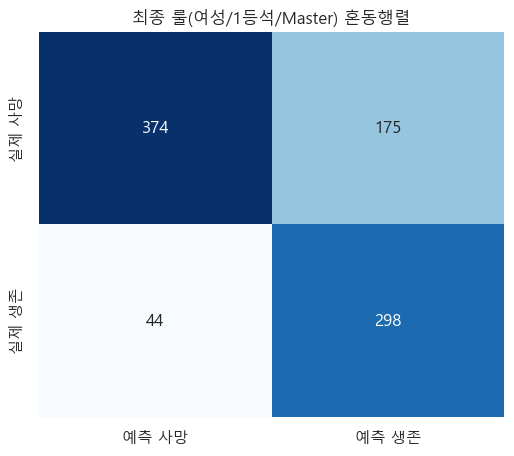

In [23]:
final_pred = ((df['성별']=='여') | (df['객실등급']==1) | (df['호칭']=='Master')).astype(int)

cm = confusion_matrix(actual, final_pred)
cm_df = pd.DataFrame(cm,
                     index=['실제 사망', '실제 생존'],
                     columns=['예측 사망', '예측 생존'])
print('혼동행렬:')
print(cm_df)
print('\n분류 리포트:')
print(classification_report(actual, final_pred, target_names=['사망', '생존'], digits=3))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'최종 룰(여성/1등석/Master) 혼동행렬')
plt.show()

**해석:**
- 실제 생존자 342명 중 **298명을 정확히 예측** (recall 87.1%)
- 룰이 "생존"이라고 한 사람 473명 중 298명이 실제 생존 (precision 63.0%)
- 즉 룰은 **놓치는 사람은 적지만 false positive가 많다** — 사망자 175명을 생존으로 잘못 예측

전형적인 룰베이스 분류의 한계: **단순한 if-then 규칙은 trade-off를 세밀하게 조절하기 어렵다.** 더 정교한 분류는 ML 모델이 필요한 영역이다.